## Colab bootstrap



In [2]:

from pathlib import Path
import os
import subprocess
import sys
import urllib.request

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # Install dependencies used by the solution notebook.
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "pandas", "numpy", "yfinance", "fastparquet", "joblib", "vectorbt",
         "catboost", "pyyaml", "pyarrow", "kaleido", "matplotlib", "nbformat"],
        check=True,
    )

from pathlib import Path
import os, zipfile, shutil

%cd /content


!rm -rf /content/project3
!git clone https://github.com/school-of-quants/mid-frequency-trading-project-3-portfolio-optimisation-NurievBogdan.git /content/project3


from google.colab import files
uploaded = files.upload()

zip_name = next(iter(uploaded.keys()))
print("Uploaded:", zip_name)


!rm -rf /content/solution
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/solution")


solution_root = None
for p in Path("/content/solution").rglob("*"):
    if p.is_dir() and (p / "equity_project").exists():
        solution_root = p
        break

if solution_root is None:
    # если в архиве файлы лежат прямо в корне
    solution_root = Path("/content/solution")

print("Solution root:", solution_root)


!cp -r "{solution_root}/"* /content/project3/


%cd /content/project3

# На всякий случай скачиваем исторический состав S&P500
!mkdir -p "equity_project/data/pony"
!wget -q -O "equity_project/data/pony/S&P_500_Historical_Components.csv" \
"https://raw.githubusercontent.com/school-of-quants/mid-frequency-trading-project-3-portfolio-optimisation-NurievBogdan/main/equity_project/data/pony/S%26P_500_Historical_Components.csv"


components_path = Path("equity_project/data/pony/S&P_500_Historical_Components.csv")
assert components_path.exists(), f"Missing file: {components_path.resolve()}"

print("OK. Project ready at:", Path.cwd())
print("Historical components:", components_path.resolve())


candidate_roots = [
    Path("/content/drive/MyDrive/project3"),
    Path("/content/project3"),
    Path.cwd(),
]

for root in candidate_roots:
    if (root / "equity_project").exists() or (root / "Project_3_Mid_Frequency_Trading_Solution.ipynb").exists():
        os.chdir(root)
        break

ROOT = Path.cwd()
print("Working directory:", ROOT)


for path in [
    ROOT / "equity_project" / "src",
    ROOT / "equity_project" / "data" / "pony",
    ROOT / "equity_project" / "data" / "raw",
    ROOT / "equity_project" / "data" / "processed",
    ROOT / "equity_project" / "artifacts" / "metrics",
    ROOT / "equity_project" / "artifacts" / "plots",
    ROOT / "equity_project" / "models",
]:
    path.mkdir(parents=True, exist_ok=True)


components_path = ROOT / "equity_project" / "data" / "pony" / "S&P_500_Historical_Components.csv"
if not components_path.exists():
    url = "https://raw.githubusercontent.com/school-of-quants/mid-frequency-trading-project-3-portfolio-optimisation-NurievBogdan/main/equity_project/data/pony/S%26P_500_Historical_Components.csv"
    print("Downloading:", url)
    urllib.request.urlretrieve(url, components_path)

assert components_path.exists(), f"Missing historical components file: {components_path}"
print("Historical S&P500 components file found:", components_path)


/content
Cloning into '/content/project3'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 41 (delta 1), reused 1 (delta 1), pack-reused 33 (from 2)
Receiving objects: 100% (41/41), 179.71 KiB | 4.28 MiB/s, done.
Resolving deltas: 100% (4/4), done.


Saving mft_solution_colab_ready.zip to mft_solution_colab_ready.zip
Uploaded: mft_solution_colab_ready.zip
Solution root: /content/solution/mft_solution_colab_ready
/content/project3
OK. Project ready at: /content/project3
Historical components: /content/project3/equity_project/data/pony/S&P_500_Historical_Components.csv
Working directory: /content/project3
Historical S&P500 components file found: /content/project3/equity_project/data/pony/S&P_500_Historical_Components.csv


In [3]:
!pip install pandas numpy yfinance fastparquet joblib vectorbt catboost pyyaml pyarrow kaleido matplotlib nbformat

from pathlib import Path


ROOT = Path.cwd()
for path in [
    ROOT / 'equity_project' / 'src',
    ROOT / 'equity_project' / 'data' / 'raw',
    ROOT / 'equity_project' / 'data' / 'processed',
    ROOT / 'equity_project' / 'artifacts' / 'metrics',
    ROOT / 'equity_project' / 'artifacts' / 'plots',
    ROOT / 'equity_project' / 'models',
]:
    path.mkdir(parents=True, exist_ok=True)

(ROOT / 'equity_project' / '__init__.py').touch()
(ROOT / 'equity_project' / 'src' / '__init__.py').touch()
print(f'Repository root: {ROOT}')

Repository root: /content/project3


In [4]:
%%writefile config.yaml
train_start_date: "2017-01-01"
train_end_date: "2022-12-31"
backtest_start_date: "2023-01-01"
backtest_end_date: "2025-12-31"

init_cash: 20000000
fees: 0.001
benchmark_ticker: "SPY"

prediction_horizon: 10
rebalance_frequency: "W-FRI"
top_n: 50
max_position_weight: 0.03
max_gross_exposure: 0.95

purge_days: 10
embargo_pct: 0.01
n_splits: 5
cpcv_n_groups: 6
cpcv_n_test_groups: 2
cpcv_max_combinations: 15
run_cpcv: true

random_seed: 42
debug: false
debug_n_tickers: 80


Overwriting config.yaml


In [5]:
%%writefile main.py
"""Project entrypoint: data preparation, model training, and portfolio backtest"""

from equity_project.src.get_data import get_data
from equity_project.src.run_backtest import run_backtest
from equity_project.src.train import train


def main() -> None:
    """Run the full research pipeline"""
    get_data()
    train()
    run_backtest()


if __name__ == "__main__":
    main()


Overwriting main.py


In [6]:
%%writefile pyproject.toml
[tool.poetry]
name = "equity_project"
version = "0.1.0"
description = "Project 3 - mid-frequency quantitative equity strategy"
authors = ["Student"]
readme = "README.md"

[tool.poetry.dependencies]
python = ">=3.10"
numpy = "^1.26.4"
pandas = "^2.2.0"
yfinance = "^0.2.66"
fastparquet = "^2024.11.0"
joblib = "^1.5.2"
vectorbt = "^0.28.5"
catboost = "^1.2.10"
pyyaml = "^6.0.3"
pyarrow = "^23.0.1"
kaleido = "^1.2.0"
matplotlib = "^3.9.0"
nbformat = "^5.10.4"

[build-system]
requires = ["poetry-core"]
build-backend = "poetry.core.masonry.api"


Overwriting pyproject.toml


In [21]:
%%writefile equity_project/src/utils.py
"""Utility functions"""

from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, Iterable, Optional

import numpy as np
import pandas as pd
from yaml import safe_load


PROJECT_PATH = Path(__file__).resolve().parents[1]
REPO_PATH = PROJECT_PATH.parent


def load_config(config_path: str | Path | None = None) -> Dict[str, Any]:
    """Load a YAML configuration file.

    Args:
        config_path: Optional path to ``config.yaml``

    Returns:
        A dictionary with configuration parameters
    """
    path = Path(config_path) if config_path is not None else REPO_PATH / "config.yaml"
    with open(path, "r", encoding="utf-8") as file:
        return safe_load(file)


def save_dict(payload: Dict[str, Any], path: str | Path) -> None:
    """
    Save a dictionary as a pretty JSON file
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as file:
        json.dump(payload, file, ensure_ascii=False, indent=4, default=str)


def clean_ticker(ticker: str) -> str:
    """
    Convert index ticker notation to yfinance-compatible notation

    """
    return str(ticker).strip().replace(".", "-")


def extract_dates(index: pd.Index | pd.MultiIndex) -> pd.DatetimeIndex:
    """
    Extract the date level from a regular or MultiIndex index

    """
    if isinstance(index, pd.MultiIndex):
        if "Date" in index.names:
            values = index.get_level_values("Date")
        else:
            values = index.get_level_values(0)
    else:
        values = index
    return pd.to_datetime(values)


def annualized_return(returns: pd.Series, periods_per_year: int = 252) -> float:
    """Calculate geometric annualized return from periodic returns"""
    returns = returns.dropna()
    if returns.empty:
        return np.nan
    total_return = (1.0 + returns).prod() - 1.0
    years = len(returns) / periods_per_year
    if years <= 0:
        return np.nan
    return float((1.0 + total_return) ** (1.0 / years) - 1.0)


def sharpe_ratio(returns: pd.Series, periods_per_year: int = 252) -> float:
    """Calculate annualized Sharpe ratio with zero risk-free rate"""
    returns = returns.dropna()
    std = returns.std(ddof=1)
    if returns.empty or std == 0 or np.isnan(std):
        return np.nan
    return float(np.sqrt(periods_per_year) * returns.mean() / std)


def max_drawdown(equity_curve: pd.Series) -> float:
    """Return maximum drawdown as a negative fraction"""
    equity_curve = equity_curve.dropna()
    if equity_curve.empty:
        return np.nan
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1.0
    return float(drawdown.min())


def max_drawdown_duration(equity_curve: pd.Series) -> int:
    """
    Calculate the longest drawdown duration in trading days
    """
    equity_curve = equity_curve.dropna()
    if equity_curve.empty:
        return 0
    underwater = equity_curve < equity_curve.cummax()
    durations = []
    current = 0
    for flag in underwater:
        if flag:
            current += 1
        else:
            durations.append(current)
            current = 0
    durations.append(current)
    return int(max(durations) if durations else 0)


def calmar_ratio(returns: pd.Series, equity_curve: Optional[pd.Series] = None) -> float:
    """Calculate Calmar ratio as annualized return divided by max drawdown"""
    if equity_curve is None:
        equity_curve = (1.0 + returns.fillna(0.0)).cumprod()
    ann_ret = annualized_return(returns)
    mdd = abs(max_drawdown(equity_curve))
    if mdd == 0 or np.isnan(mdd):
        return np.nan
    return float(ann_ret / mdd)


def safe_dataframe_to_parquet(frame: pd.DataFrame, path: str | Path) -> None:
    """Save a dataframe to parquet and create the parent directory if needed"""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_parquet(path, engine="pyarrow")


def rolling_pairwise_ipc(
    returns: pd.DataFrame,
    weights: pd.DataFrame,
    window: int = 63,
    min_assets: int = 3,
    rebalance_only: bool = True,
) -> pd.Series:
    """Calculate rolling intra-portfolio correlation (IPC).

    For each date, the function selects assets with positive portfolio weights,
    estimates a rolling correlation matrix from historical returns, and then
    computes a weighted average of pairwise correlations. The loops are over
    rebalance dates only

    Args:
        returns: Daily asset returns with dates as rows and tickers as columns.
        weights: Portfolio weights aligned to the same date/ticker grid.
        window: Rolling lookback window for correlations.
        min_assets: Minimum number of selected assets needed to compute IPC.
        rebalance_only: If True, compute IPC only when weights change.

    Returns:
        A series indexed by date with IPC values
    """
    common_index = returns.index.intersection(weights.index)
    returns = returns.loc[common_index]
    weights = weights.loc[common_index, returns.columns]

    if rebalance_only:
        changed = weights.diff().abs().sum(axis=1).fillna(1.0) > 1e-12
        evaluation_dates = weights.index[changed]
    else:
        evaluation_dates = weights.index

    ipc_values: Dict[pd.Timestamp, float] = {}
    for dt in evaluation_dates:
        pos = weights.loc[dt]
        selected = pos[pos > 0].index.tolist()
        if len(selected) < min_assets:
            ipc_values[dt] = np.nan
            continue

        hist = returns.loc[:dt, selected].tail(window).dropna(axis=1, how="any")
        if hist.shape[0] < max(20, window // 3) or hist.shape[1] < min_assets:
            ipc_values[dt] = np.nan
            continue

        corr = hist.corr().values
        selected_after_drop = hist.columns
        w = pos.loc[selected_after_drop].values.astype(float)
        w_sum = w.sum()
        if w_sum <= 0:
            ipc_values[dt] = np.nan
            continue
        w = w / w_sum

        pair_weights = np.outer(w, w)
        mask = ~np.eye(len(w), dtype=bool)
        denom = pair_weights[mask].sum()
        ipc_values[dt] = float((corr[mask] * pair_weights[mask]).sum() / denom) if denom > 0 else np.nan

    result = pd.Series(ipc_values, name="ipc")
    return result.reindex(weights.index).ffill()


def average_universe_ipc(
    returns: pd.DataFrame,
    membership: pd.DataFrame,
    window: int = 63,
    min_assets: int = 20,
    evaluation_index: Optional[Iterable[pd.Timestamp]] = None,
) -> pd.Series:
    """
    Calculate equal-weight IPC for the investable S&P500 universe.

    """
    membership = membership.reindex(returns.index).fillna(False).astype(bool)
    eval_dates = pd.Index(evaluation_index if evaluation_index is not None else returns.index)
    ipc_values: Dict[pd.Timestamp, float] = {}

    for dt in eval_dates:
        if dt not in returns.index:
            continue
        selected = membership.loc[dt]
        tickers = selected[selected].index.intersection(returns.columns)
        if len(tickers) < min_assets:
            ipc_values[dt] = np.nan
            continue
        hist = returns.loc[:dt, tickers].tail(window).dropna(axis=1, how="any")
        if hist.shape[0] < max(20, window // 3) or hist.shape[1] < min_assets:
            ipc_values[dt] = np.nan
            continue
        corr = hist.corr().values
        mask = ~np.eye(corr.shape[0], dtype=bool)
        ipc_values[dt] = float(np.nanmean(corr[mask]))

    result = pd.Series(ipc_values, name="sp500_universe_ipc")
    return result.reindex(returns.index).ffill()


Overwriting equity_project/src/utils.py


In [22]:
%%writefile equity_project/src/validation.py
"""
Purged time-series cross-validation utilities

"""

from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from typing import Iterator, Tuple

import numpy as np
import pandas as pd

from equity_project.src.utils import extract_dates


@dataclass
class PurgedKFold:
    """
    K-fold cross-validation with purging and embargo

    """

    n_splits: int = 5
    purge_days: int = 10
    embargo_pct: float = 0.01

    def split(self, X: pd.DataFrame) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        """Yield train/test positional indices for each purged fold"""
        sample_dates = extract_dates(X.index)
        unique_dates = pd.DatetimeIndex(sorted(sample_dates.unique()))
        date_folds = np.array_split(unique_dates, self.n_splits)
        embargo_n = max(1, int(len(unique_dates) * self.embargo_pct))

        for test_dates in date_folds:
            if len(test_dates) == 0:
                continue
            test_start = test_dates[0]
            test_end = test_dates[-1]
            test_end_pos = unique_dates.searchsorted(test_end)
            embargo_end_pos = min(len(unique_dates) - 1, test_end_pos + embargo_n)
            embargo_end = unique_dates[embargo_end_pos]
            purge_start = test_start - pd.Timedelta(days=self.purge_days)

            test_mask = sample_dates.isin(test_dates)
            train_mask = ~((sample_dates >= purge_start) & (sample_dates <= embargo_end))
            yield np.flatnonzero(train_mask), np.flatnonzero(test_mask)


@dataclass
class CombinatorialPurgedCV:
    """
    Combinatorial Purged Cross-Validation splitter

    """

    n_groups: int = 6
    n_test_groups: int = 2
    purge_days: int = 10
    embargo_pct: float = 0.01
    max_combinations: int | None = None

    def split(self, X: pd.DataFrame) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        """Yield train/test positional indices for CPCV folds"""
        sample_dates = extract_dates(X.index)
        unique_dates = pd.DatetimeIndex(sorted(sample_dates.unique()))
        date_groups = np.array_split(unique_dates, self.n_groups)
        embargo_n = max(1, int(len(unique_dates) * self.embargo_pct))

        combos = list(combinations(range(self.n_groups), self.n_test_groups))
        if self.max_combinations is not None:
            combos = combos[: self.max_combinations]

        for combo in combos:
            test_dates = pd.DatetimeIndex([])
            blocked_mask = np.zeros(len(sample_dates), dtype=bool)
            for group_id in combo:
                group_dates = pd.DatetimeIndex(date_groups[group_id])
                if len(group_dates) == 0:
                    continue
                test_dates = test_dates.union(group_dates)

                test_start = group_dates[0]
                test_end = group_dates[-1]
                test_end_pos = unique_dates.searchsorted(test_end)
                embargo_end_pos = min(len(unique_dates) - 1, test_end_pos + embargo_n)
                embargo_end = unique_dates[embargo_end_pos]
                purge_start = test_start - pd.Timedelta(days=self.purge_days)
                blocked_mask |= (sample_dates >= purge_start) & (sample_dates <= embargo_end)

            test_mask = sample_dates.isin(test_dates)
            train_mask = ~blocked_mask
            train_mask &= ~test_mask
            yield np.flatnonzero(train_mask), np.flatnonzero(test_mask)


Overwriting equity_project/src/validation.py


In [9]:
%%writefile equity_project/src/get_data.py
"""Data ingestion, S&P500 membership handling, feature engineering, and labeling"""

from __future__ import annotations

import warnings
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd
import yfinance as yf

from equity_project.src.utils import (
    PROJECT_PATH,
    clean_ticker,
    load_config,
    safe_dataframe_to_parquet,
    save_dict,
)

warnings.filterwarnings("ignore")


TRASH_TICKERS = {"DEC", "USBC", "CPWR", "TNB", "APP", "BMC", "SBNY"}


def parse_component_list(value: str) -> list[str]:
    if pd.isna(value):
        return []
    return [clean_ticker(ticker) for ticker in str(value).split(",") if str(ticker).strip()]


def load_historical_components(path: str | Path) -> pd.Series:
    """
    Load historical S&P500 constituents from the provided CSV file.

    """
    components = pd.read_csv(path, index_col=0)
    components.index = pd.to_datetime(components.index)
    # The baseline file stores the comma-separated constituents in the first
    # data column. The exact column name is not important.
    constituents = components.iloc[:, 0].apply(parse_component_list)
    constituents = constituents.sort_index()
    return constituents


def get_all_historical_tickers(components: pd.Series) -> list[str]:
    """Return a sorted list of all tickers that ever appeared in the index"""
    tickers = sorted({ticker for ticker_list in components for ticker in ticker_list})
    return [ticker for ticker in tickers if ticker not in TRASH_TICKERS]


def build_membership_matrix(components: pd.Series, trading_index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Build a daily S&P500 membership matrix aligned to trading dates

    The baseline only drops observations before the first index entry. This
    implementation is stricter: a stock is investable only on dates when the
    historical component file says it was actually a member of the index
    """
    tickers = get_all_historical_tickers(components)
    membership_snapshots = pd.DataFrame(False, index=components.index, columns=tickers)
    for dt, ticker_list in components.items():
        valid = [ticker for ticker in ticker_list if ticker in membership_snapshots.columns]
        membership_snapshots.loc[dt, valid] = True

    membership = membership_snapshots.reindex(pd.DatetimeIndex(trading_index), method="ffill")
    membership = membership.fillna(False).astype(bool)
    membership.index.name = "Date"
    return membership


def normalize_yfinance_columns(data: pd.DataFrame, tickers: Iterable[str]) -> pd.DataFrame:
    """Normalize yfinance output to a two-level ``(Field, Ticker)`` column index."""
    if not isinstance(data.columns, pd.MultiIndex):
        # yfinance returns a flat frame for a single ticker.
        ticker = next(iter(tickers))
        data.columns = pd.MultiIndex.from_product([data.columns, [ticker]])
    if "Adj Close" in data.columns.get_level_values(0):
        data = data.drop(columns="Adj Close", level=0)
    data = data.sort_index(axis=1)
    data.index = pd.to_datetime(data.index)
    data.index.name = "Date"
    return data.astype(float)


def download_ohlcv(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """
    Download adjusted OHLCV data from Yahoo Finance

    """
    data = yf.download(
        tickers=tickers,
        start=start,
        end=(pd.Timestamp(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        group_by="column",
        auto_adjust=True,
        threads=True,
        progress=True,
    )
    data = normalize_yfinance_columns(data, tickers)
    return data


def download_benchmark(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Download a benchmark ETF/index series for comparison with the strategy"""
    benchmark = yf.download(
        ticker,
        start=start,
        end=(pd.Timestamp(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
    )
    benchmark.index = pd.to_datetime(benchmark.index)
    benchmark.index.name = "Date"
    return benchmark.astype(float)


def generate_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Generate vectorized price, volatility, volume, and cross-sectional features

    """
    close = data["Close"].replace(0, np.nan)
    open_ = data["Open"].replace(0, np.nan)
    high = data["High"].replace(0, np.nan)
    low = data["Low"].replace(0, np.nan)
    volume = data["Volume"].replace(0, np.nan)
    returns = close.pct_change()

    features: Dict[str, pd.DataFrame] = {}

    for window in (1, 5, 10, 21, 63, 126, 252):
        ret = close.pct_change(window)
        features[f"ret_{window}"] = ret
        features[f"ret_rank_{window}"] = ret.rank(axis=1, pct=True)

    for window in (5, 21, 63, 126, 252):
        ma = close.rolling(window).mean()
        features[f"ma_dev_{window}"] = close / ma - 1.0
        vol = returns.rolling(window).std() * np.sqrt(252)
        features[f"vol_{window}"] = vol
        features[f"vol_rank_{window}"] = vol.rank(axis=1, pct=True)

    features["ma_50_200"] = close.rolling(50).mean() / close.rolling(200).mean() - 1.0
    features["high_low_range"] = (high - low) / close
    features["intraday_ret"] = close / open_ - 1.0
    features["overnight_ret"] = open_ / close.shift(1) - 1.0

    log_volume = np.log1p(volume)
    features["volume_z_21"] = (log_volume - log_volume.rolling(21).mean()) / log_volume.rolling(21).std()
    dollar_volume = close * volume
    features["dollar_volume_rank_21"] = dollar_volume.rolling(21).mean().rank(axis=1, pct=True)

    rolling_high = high.rolling(63).max()
    rolling_low = low.rolling(63).min()
    features["donchian_pos_63"] = (close - rolling_low) / (rolling_high - rolling_low)


    for window in (5, 21, 63):
        ret = close.pct_change(window)
        features[f"ret_cs_z_{window}"] = ret.sub(ret.mean(axis=1), axis=0).div(ret.std(axis=1), axis=0)

    X = pd.concat(features, axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.shift(1)
    X = X.iloc[260:]
    X.index.name = "Date"
    return X


def generate_target(close: pd.DataFrame, horizon: int = 10) -> pd.DataFrame:
    """
    Create a 3-class cross-sectional target from forward excess returns
    """
    forward_return = close.shift(-horizon) / close - 1.0
    excess_return = forward_return.sub(forward_return.mean(axis=1), axis=0)
    ranks = excess_return.rank(axis=1, pct=True)

    target = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    target = target.mask(ranks <= 0.30, 0)
    target = target.mask((ranks > 0.30) & (ranks < 0.70), 1)
    target = target.mask(ranks >= 0.70, 2)
    target[forward_return.isna()] = np.nan
    target.index.name = "Date"
    return target


def stack_feature_frame(X: pd.DataFrame) -> pd.DataFrame:
    X_long = X.stack(level=1)
    X_long.index.names = ["Date", "Ticker"]
    X_long = X_long.sort_index()
    return X_long


def stack_target_frame(y: pd.DataFrame) -> pd.DataFrame:
    y_long = y.stack().rename("target").to_frame()
    y_long.index.names = ["Date", "Ticker"]
    return y_long.sort_index()


def get_raw_data() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cfg = load_config()
    start = cfg["train_start_date"]
    end = cfg["backtest_end_date"]
    components_path = PROJECT_PATH / "data" / "pony" / "S&P_500_Historical_Components.csv"

    components = load_historical_components(components_path)
    tickers = get_all_historical_tickers(components)
    if cfg.get("debug", False):
        tickers = tickers[: int(cfg.get("debug_n_tickers", 80))]

    data = download_ohlcv(tickers, start, end)
    close = data["Close"]
    available_tickers = close.columns[close.notna().sum() > 100].tolist()
    missing_tickers = sorted(set(tickers) - set(available_tickers))
    data = data.loc[:, pd.IndexSlice[:, available_tickers]]

    membership = build_membership_matrix(components, data.index)
    membership = membership.reindex(columns=available_tickers).fillna(False).astype(bool)

    benchmark = download_benchmark(cfg.get("benchmark_ticker", "SPY"), start, end)

    save_dict({"missing_tickers": missing_tickers}, PROJECT_PATH / "artifacts" / "metrics" / "missing_tickers.json")
    return data, benchmark, membership


def get_data() -> None:
    """Create and persist all raw and processed datasets used by the strategy"""
    cfg = load_config()
    data, benchmark, membership = get_raw_data()

    X = generate_features(data)
    y = generate_target(data["Close"], horizon=int(cfg.get("prediction_horizon", 10)))

    X_long = stack_feature_frame(X)
    y_long = stack_target_frame(y)
    membership_long = membership.stack().rename("is_member").to_frame()
    membership_long.index.names = ["Date", "Ticker"]

    common_index = X_long.index.intersection(y_long.index).intersection(membership_long.index)
    X_long = X_long.loc[common_index]
    y_long = y_long.loc[common_index]
    membership_long = membership_long.loc[common_index]

    # The ML sample exists only when the stock was actually in the S&P500 on
    # that date. This removes both pre-entry and post-exit survivorship bias.
    investable_index = membership_long.index[membership_long["is_member"]]
    X_long = X_long.loc[investable_index]
    y_long = y_long.loc[investable_index]

    X_long = X_long.dropna(how="all")
    y_long = y_long.loc[X_long.index]

    train_start = pd.Timestamp(cfg["train_start_date"])
    train_end = pd.Timestamp(cfg["train_end_date"])
    bt_start = pd.Timestamp(cfg["backtest_start_date"])
    bt_end = pd.Timestamp(cfg["backtest_end_date"])

    dates = X_long.index.get_level_values("Date")
    train_mask = (dates >= train_start) & (dates <= train_end)
    backtest_mask = (dates >= bt_start) & (dates <= bt_end)

    safe_dataframe_to_parquet(data.loc[train_start:train_end], PROJECT_PATH / "data" / "raw" / "train_data.parquet")
    safe_dataframe_to_parquet(data.loc[bt_start:bt_end], PROJECT_PATH / "data" / "raw" / "backtest_data.parquet")
    safe_dataframe_to_parquet(benchmark.loc[train_start:bt_end], PROJECT_PATH / "data" / "raw" / "benchmark.parquet")
    safe_dataframe_to_parquet(membership.loc[train_start:bt_end], PROJECT_PATH / "data" / "processed" / "membership.parquet")

    safe_dataframe_to_parquet(X_long.loc[train_mask], PROJECT_PATH / "data" / "processed" / "X_train.parquet")
    safe_dataframe_to_parquet(y_long.loc[train_mask], PROJECT_PATH / "data" / "processed" / "y_train.parquet")
    safe_dataframe_to_parquet(X_long.loc[backtest_mask], PROJECT_PATH / "data" / "processed" / "X_backtest.parquet")
    safe_dataframe_to_parquet(y_long.loc[backtest_mask], PROJECT_PATH / "data" / "processed" / "y_backtest.parquet")


if __name__ == "__main__":
    get_data()


Overwriting equity_project/src/get_data.py


In [10]:
%%writefile equity_project/src/train.py
"""Model training with PurgedKFold and CPCV diagnostics"""

from __future__ import annotations

import os
from pathlib import Path
from typing import Dict, Tuple

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

from equity_project.src.utils import PROJECT_PATH, extract_dates, load_config, safe_dataframe_to_parquet, save_dict
from equity_project.src.validation import CombinatorialPurgedCV, PurgedKFold


def instantiate_model(random_seed: int = 42, iterations: int = 500) -> CatBoostClassifier:
    """
    Create the CatBoost classifier used for stock ranking
    """
    return CatBoostClassifier(
        iterations=iterations,
        depth=6,
        learning_rate=0.035,
        l2_leaf_reg=8.0,
        loss_function="MultiClass",
        eval_metric="MultiClass",
        auto_class_weights="Balanced",
        random_seed=random_seed,
        early_stopping_rounds=60,
        allow_writing_files=False,
        verbose=False,
    )


def load_training_dataset() -> Tuple[pd.DataFrame, pd.Series]:
    X = pd.read_parquet(PROJECT_PATH / "data" / "processed" / "X_train.parquet")
    y = pd.read_parquet(PROJECT_PATH / "data" / "processed" / "y_train.parquet")["target"]

    common_index = X.index.intersection(y.index)
    X = X.loc[common_index].replace([np.inf, -np.inf], np.nan)
    y = y.loc[common_index]

    valid = y.notna()
    X = X.loc[valid]
    y = y.loc[valid].astype(int)

    keep_cols = X.isna().mean() < 0.95
    X = X.loc[:, keep_cols]
    X = X.sort_index()
    y = y.loc[X.index]
    return X, y


def multiclass_logloss(y_true: np.ndarray, proba: np.ndarray) -> float:
    """Compute multiclass log-loss without depending on sklearn"""
    eps = 1e-12
    proba = np.clip(proba, eps, 1.0 - eps)
    proba = proba / proba.sum(axis=1, keepdims=True)
    return float(-np.mean(np.log(proba[np.arange(len(y_true)), y_true.astype(int)])))


def evaluate_proba(y_true: pd.Series, proba: np.ndarray) -> Dict[str, float]:
    """Return lightweight classification metrics for probability predictions"""
    pred_class = proba.argmax(axis=1)
    y_arr = y_true.values.astype(int)
    return {
        "accuracy": float((pred_class == y_arr).mean()),
        "logloss": multiclass_logloss(y_arr, proba),
    }


def run_purged_kfold_cv(X: pd.DataFrame, y: pd.Series, cfg: Dict) -> pd.DataFrame:
    """Run PurgedKFold validation and return fold-level model metrics"""
    cv = PurgedKFold(
        n_splits=int(cfg.get("n_splits", 5)),
        purge_days=int(cfg.get("purge_days", 10)),
        embargo_pct=float(cfg.get("embargo_pct", 0.01)),
    )
    rows = []
    for fold_id, (train_idx, val_idx) in enumerate(cv.split(X), start=1):
        if len(train_idx) == 0 or len(val_idx) == 0:
            continue
        model = instantiate_model(random_seed=int(cfg.get("random_seed", 42)) + fold_id, iterations=350)
        model.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=(X.iloc[val_idx], y.iloc[val_idx]))
        proba = model.predict_proba(X.iloc[val_idx])
        metrics = evaluate_proba(y.iloc[val_idx], proba)
        val_dates = extract_dates(X.iloc[val_idx].index)
        rows.append(
            {
                "fold": fold_id,
                "train_samples": int(len(train_idx)),
                "validation_samples": int(len(val_idx)),
                "validation_start": str(val_dates.min().date()),
                "validation_end": str(val_dates.max().date()),
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def run_cpcv_oos_predictions(X: pd.DataFrame, y: pd.Series, cfg: Dict) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Generate out-of-sample predictions using Combinatorial Purged CV"""
    cv = CombinatorialPurgedCV(
        n_groups=int(cfg.get("cpcv_n_groups", 6)),
        n_test_groups=int(cfg.get("cpcv_n_test_groups", 2)),
        purge_days=int(cfg.get("purge_days", 10)),
        embargo_pct=float(cfg.get("embargo_pct", 0.01)),
        max_combinations=cfg.get("cpcv_max_combinations", None),
    )

    prediction_frames = []
    metric_rows = []
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(X), start=1):
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        model = instantiate_model(random_seed=int(cfg.get("random_seed", 42)) + 100 + fold_id, iterations=300)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = model.predict_proba(X.iloc[test_idx])
        pred = pd.DataFrame(proba, index=X.iloc[test_idx].index, columns=[0, 1, 2])
        pred["fold"] = fold_id
        prediction_frames.append(pred)

        metrics = evaluate_proba(y.iloc[test_idx], proba)
        test_dates = extract_dates(X.iloc[test_idx].index)
        metric_rows.append(
            {
                "fold": fold_id,
                "train_samples": int(len(train_idx)),
                "test_samples": int(len(test_idx)),
                "test_start": str(test_dates.min().date()),
                "test_end": str(test_dates.max().date()),
                **metrics,
            }
        )

    if not prediction_frames:
        return pd.DataFrame(), pd.DataFrame(metric_rows)

    all_preds = pd.concat(prediction_frames).sort_index()
    averaged_preds = all_preds[[0, 1, 2]].groupby(level=["Date", "Ticker"]).mean()
    metrics = pd.DataFrame(metric_rows)
    return averaged_preds, metrics


def chronological_train_eval_split(X: pd.DataFrame, y: pd.Series, eval_fraction: float = 0.20) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Create the final chronological train/evaluation split for early stopping"""
    dates = pd.DatetimeIndex(sorted(extract_dates(X.index).unique()))
    split_point = int(len(dates) * (1.0 - eval_fraction))
    eval_start = dates[max(0, min(split_point, len(dates) - 1))]
    sample_dates = extract_dates(X.index)
    train_mask = sample_dates < eval_start
    eval_mask = sample_dates >= eval_start
    return X.loc[train_mask], X.loc[eval_mask], y.loc[train_mask], y.loc[eval_mask]


def train() -> None:
    os.makedirs(PROJECT_PATH / "models", exist_ok=True)
    os.makedirs(PROJECT_PATH / "artifacts" / "metrics", exist_ok=True)

    cfg = load_config()
    X, y = load_training_dataset()

    feature_columns = list(X.columns)
    save_dict({"feature_columns": feature_columns}, PROJECT_PATH / "models" / "feature_columns.json")

    purged_metrics = run_purged_kfold_cv(X, y, cfg)
    safe_dataframe_to_parquet(purged_metrics, PROJECT_PATH / "artifacts" / "metrics" / "purged_kfold_metrics.parquet")
    save_dict(
        {
            "purged_kfold_mean_accuracy": float(purged_metrics["accuracy"].mean()) if not purged_metrics.empty else None,
            "purged_kfold_mean_logloss": float(purged_metrics["logloss"].mean()) if not purged_metrics.empty else None,
            "folds": purged_metrics.to_dict(orient="records"),
        },
        PROJECT_PATH / "artifacts" / "metrics" / "purged_kfold_metrics.json",
    )

    if bool(cfg.get("run_cpcv", True)):
        cpcv_preds, cpcv_metrics = run_cpcv_oos_predictions(X, y, cfg)
        if not cpcv_preds.empty:
            safe_dataframe_to_parquet(cpcv_preds, PROJECT_PATH / "data" / "processed" / "cpcv_oos_predictions.parquet")
        safe_dataframe_to_parquet(cpcv_metrics, PROJECT_PATH / "artifacts" / "metrics" / "cpcv_model_metrics.parquet")
        save_dict(
            {
                "cpcv_mean_accuracy": float(cpcv_metrics["accuracy"].mean()) if not cpcv_metrics.empty else None,
                "cpcv_mean_logloss": float(cpcv_metrics["logloss"].mean()) if not cpcv_metrics.empty else None,
                "folds": cpcv_metrics.to_dict(orient="records"),
            },
            PROJECT_PATH / "artifacts" / "metrics" / "cpcv_model_metrics.json",
        )

    X_train, X_eval, y_train, y_eval = chronological_train_eval_split(X, y)
    model = instantiate_model(random_seed=int(cfg.get("random_seed", 42)), iterations=700)
    model.fit(X_train, y_train, eval_set=(X_eval, y_eval))
    joblib.dump(model, PROJECT_PATH / "models" / "model.joblib")


if __name__ == "__main__":
    train()


Overwriting equity_project/src/train.py


In [11]:
%%writefile equity_project/src/run_backtest.py
"""Portfolio construction, final holdout backtest, CPCV backtest, and metrics"""

from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Dict, Tuple

import joblib
import numpy as np
import pandas as pd
import vectorbt as vbt

from equity_project.src.utils import (
    PROJECT_PATH,
    average_universe_ipc,
    calmar_ratio,
    max_drawdown,
    max_drawdown_duration,
    rolling_pairwise_ipc,
    save_dict,
    sharpe_ratio,
)
from equity_project.src.utils import load_config


def load_feature_columns() -> list[str]:
    with open(PROJECT_PATH / "models" / "feature_columns.json", "r", encoding="utf-8") as file:
        payload = json.load(file)
    return payload["feature_columns"]


def predict_model_scores(model, X: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    """Run model inference and return class probabilities indexed by Date/Ticker"""
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.reindex(columns=feature_columns)
    proba = model.predict_proba(X)
    return pd.DataFrame(proba, index=X.index, columns=[0, 1, 2])


def get_rebalance_dates(index: pd.DatetimeIndex, frequency: str) -> pd.DatetimeIndex:
    """Return last available trading date in every rebalance period"""
    idx = pd.DatetimeIndex(index).sort_values().unique()
    last_dates = idx.to_series(index=idx).groupby(idx.to_period(frequency)).max()
    return pd.DatetimeIndex(last_dates.values)


def generate_weights(
    preds: pd.DataFrame,
    membership: pd.DataFrame,
    top_n: int = 50,
    max_position_weight: float = 0.03,
    max_gross_exposure: float = 0.95,
    rebalance_frequency: str = "W-FRI",
) -> pd.DataFrame:
    """
    Convert class probabilities into long-only target portfolio weights

    The score is ``P(outperform) - P(underperform)``. At each rebalance date the
    strategy buys only the top-ranked positive-score S&P500 members. Weights are
    score-proportional, capped by name, and scaled so gross exposure never
    exceeds ``max_gross_exposure``
    """
    score = (preds[2] - preds[0]).unstack("Ticker").sort_index()
    membership = membership.reindex(index=score.index, columns=score.columns).fillna(False).astype(bool)
    score = score.where(membership)

    rebalance_dates = get_rebalance_dates(score.index, rebalance_frequency)
    score_rebalanced = score.loc[score.index.intersection(rebalance_dates)]

    ranks = score_rebalanced.rank(axis=1, ascending=False, method="first")
    selected = (ranks <= top_n) & (score_rebalanced > 0)
    raw_weights = score_rebalanced.clip(lower=0).where(selected, 0.0).fillna(0.0)

    row_sums = raw_weights.sum(axis=1).replace(0.0, np.nan)
    weights = raw_weights.div(row_sums, axis=0).fillna(0.0)
    weights = weights.clip(upper=max_position_weight)

    gross = weights.sum(axis=1).replace(0.0, np.nan)
    scale = (max_gross_exposure / gross).clip(upper=1.0).fillna(0.0)
    weights = weights.mul(scale, axis=0)

    weights = weights.reindex(score.index).ffill().fillna(0.0)
    return weights


def get_twap_price(data: pd.DataFrame) -> pd.DataFrame:
    return (data["Open"] + data["High"] + data["Low"] + data["Close"]) / 4.0


def extract_benchmark_close(benchmark: pd.DataFrame) -> pd.Series:
    """Extract a single benchmark close series from a yfinance dataframe"""
    if isinstance(benchmark.columns, pd.MultiIndex):
        close = benchmark.xs("Close", axis=1, level=0)
        if isinstance(close, pd.DataFrame):
            return close.iloc[:, 0].rename("benchmark_close")
        return close.rename("benchmark_close")
    if "Close" in benchmark.columns:
        return benchmark["Close"].rename("benchmark_close")
    if "Adj Close" in benchmark.columns:
        return benchmark["Adj Close"].rename("benchmark_close")
    raise KeyError("Benchmark dataframe must contain Close or Adj Close column")


def run_vectorbt_portfolio(
    close: pd.DataFrame,
    execution_price: pd.DataFrame,
    weights: pd.DataFrame,
    init_cash: float,
    fees: float,
) -> vbt.Portfolio:
    """Create a vectorbt target-percent portfolio with shared cash"""
    common_cols = close.columns.intersection(weights.columns).intersection(execution_price.columns)
    close = close.loc[:, common_cols].dropna(axis=1, how="all")
    execution_price = execution_price.loc[:, close.columns]
    weights = weights.reindex(index=close.index).ffill().reindex(columns=close.columns).fillna(0.0)

    return vbt.Portfolio.from_orders(
        close=close,
        price=execution_price,
        size=weights,
        size_type="targetpercent",
        group_by=True,
        cash_sharing=True,
        freq="1d",
        init_cash=init_cash,
        fees=fees,
    )


def calculate_metrics(
    strategy_value: pd.Series,
    benchmark_close: pd.Series,
    weights: pd.DataFrame,
    cfg: Dict,
) -> Dict[str, float | str | bool]:
    strategy_value = strategy_value.dropna()
    strategy_returns = strategy_value.pct_change().fillna(0.0)

    benchmark_close = benchmark_close.reindex(strategy_value.index).ffill().dropna()
    benchmark_value = benchmark_close / benchmark_close.iloc[0] * float(cfg["init_cash"])
    benchmark_returns = benchmark_value.pct_change().fillna(0.0)

    strategy_total_return = float(strategy_value.iloc[-1] / strategy_value.iloc[0] - 1.0)
    benchmark_total_return = float(benchmark_value.iloc[-1] / benchmark_value.iloc[0] - 1.0)
    strategy_mdd = max_drawdown(strategy_value)
    benchmark_mdd = max_drawdown(benchmark_value)
    mdd_duration = max_drawdown_duration(strategy_value)
    max_gross = float(weights.abs().sum(axis=1).max()) if not weights.empty else np.nan
    min_weight = float(weights.min().min()) if not weights.empty else np.nan

    metrics = {
        "strategy_total_return": strategy_total_return,
        "benchmark_total_return": benchmark_total_return,
        "strategy_sharpe": sharpe_ratio(strategy_returns),
        "benchmark_sharpe": sharpe_ratio(benchmark_returns),
        "strategy_calmar": calmar_ratio(strategy_returns, strategy_value),
        "benchmark_calmar": calmar_ratio(benchmark_returns, benchmark_value),
        "strategy_max_drawdown": strategy_mdd,
        "benchmark_max_drawdown": benchmark_mdd,
        "strategy_max_drawdown_duration_trading_days": mdd_duration,
        "max_gross_exposure": max_gross,
        "min_weight": min_weight,
        "transaction_cost_per_trade": float(cfg["fees"]),
        "execution_model": "TWAP proxy: execution at daily OHLC average",
        "constraint_total_return_positive": bool(strategy_total_return > 0.0),
        "constraint_max_drawdown_lt_20pct": bool(abs(strategy_mdd) < 0.20),
        "constraint_max_drawdown_period_lt_6m": bool(mdd_duration < 126),
        "constraint_no_leverage": bool(max_gross <= 1.000001 and min_weight >= -1e-12),
        "beats_benchmark_by_sharpe": bool(sharpe_ratio(strategy_returns) > sharpe_ratio(benchmark_returns)),
    }
    return metrics


def save_backtest_plots(
    strategy_value: pd.Series,
    benchmark_close: pd.Series,
    ipc: pd.DataFrame,
    output_dir: Path,
    init_cash: float,
    artifact_prefix: str = "backtest",
) -> None:

    import matplotlib.pyplot as plt

    output_dir.mkdir(parents=True, exist_ok=True)
    file_prefix = "" if artifact_prefix == "backtest" else f"{artifact_prefix}_"
    benchmark_close = benchmark_close.reindex(strategy_value.index).ffill().dropna()
    benchmark_value = benchmark_close / benchmark_close.iloc[0] * init_cash

    ax = strategy_value.rename("Strategy").plot(figsize=(12, 6), title="Strategy vs S&P500 benchmark")
    benchmark_value.rename("Benchmark").plot(ax=ax)
    ax.set_ylabel("Portfolio value, USD")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(output_dir / f"{file_prefix}pnl.png", dpi=160)
    plt.close(fig)

    drawdown = strategy_value / strategy_value.cummax() - 1.0
    ax = drawdown.rename("Strategy drawdown").plot(figsize=(12, 4), title="Strategy drawdown")
    ax.set_ylabel("Drawdown")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(output_dir / f"{file_prefix}drawdown.png", dpi=160)
    plt.close(fig)

    if not ipc.empty:
        ax = ipc.plot(figsize=(12, 5), title="Intra-portfolio correlation dynamics")
        ax.set_ylabel("Rolling correlation")
        fig = ax.get_figure()
        fig.tight_layout()
        fig.savefig(output_dir / f"{file_prefix}ipc.png", dpi=160)
        plt.close(fig)


def run_single_backtest(
    preds: pd.DataFrame,
    price_data: pd.DataFrame,
    benchmark_close: pd.Series,
    membership: pd.DataFrame,
    cfg: Dict,
    artifact_prefix: str = "backtest",
) -> Dict:
    close = price_data["Close"].dropna(axis=1, how="all")
    twap_price = get_twap_price(price_data).reindex(columns=close.columns)

    weights = generate_weights(
        preds=preds,
        membership=membership,
        top_n=int(cfg.get("top_n", 50)),
        max_position_weight=float(cfg.get("max_position_weight", 0.03)),
        max_gross_exposure=float(cfg.get("max_gross_exposure", 0.95)),
        rebalance_frequency=str(cfg.get("rebalance_frequency", "W-FRI")),
    )
    weights = weights.reindex(index=close.index).ffill().reindex(columns=close.columns).fillna(0.0)

    portfolio = run_vectorbt_portfolio(
        close=close,
        execution_price=twap_price,
        weights=weights,
        init_cash=float(cfg["init_cash"]),
        fees=float(cfg["fees"]),
    )
    strategy_value = portfolio.value()
    if isinstance(strategy_value, pd.DataFrame):
        strategy_value = strategy_value.iloc[:, 0]
    strategy_value.name = "strategy_value"

    asset_returns = close.pct_change()
    strategy_ipc = rolling_pairwise_ipc(asset_returns, weights, window=63)
    universe_ipc = average_universe_ipc(
        asset_returns,
        membership.reindex(index=asset_returns.index, columns=asset_returns.columns).fillna(False),
        window=63,
        evaluation_index=strategy_ipc.dropna().index,
    )
    ipc = pd.concat([strategy_ipc.rename("strategy_ipc"), universe_ipc.rename("sp500_universe_ipc")], axis=1)

    metrics = calculate_metrics(strategy_value, benchmark_close, weights, cfg)

    metrics_dir = PROJECT_PATH / "artifacts" / "metrics"
    plots_dir = PROJECT_PATH / "artifacts" / "plots"
    metrics_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)

    strategy_value.to_frame().to_parquet(metrics_dir / f"{artifact_prefix}_equity_curve.parquet")
    weights.to_parquet(metrics_dir / f"{artifact_prefix}_weights.parquet")
    ipc.to_parquet(metrics_dir / f"{artifact_prefix}_ipc.parquet")
    save_dict(metrics, metrics_dir / f"{artifact_prefix}_metrics.json")
    save_backtest_plots(strategy_value, benchmark_close, ipc, plots_dir, float(cfg["init_cash"]), artifact_prefix=artifact_prefix)
    return metrics


def run_cpcv_backtest_if_available(cfg: Dict) -> None:
    preds_path = PROJECT_PATH / "data" / "processed" / "cpcv_oos_predictions.parquet"
    train_price_path = PROJECT_PATH / "data" / "raw" / "train_data.parquet"
    membership_path = PROJECT_PATH / "data" / "processed" / "membership.parquet"
    benchmark_path = PROJECT_PATH / "data" / "raw" / "benchmark.parquet"
    if not preds_path.exists() or not train_price_path.exists():
        return

    preds = pd.read_parquet(preds_path)
    train_data = pd.read_parquet(train_price_path)
    membership = pd.read_parquet(membership_path)
    benchmark_close = extract_benchmark_close(pd.read_parquet(benchmark_path))

    train_dates = train_data.index
    membership = membership.reindex(train_dates).fillna(False).astype(bool)
    run_single_backtest(
        preds=preds,
        price_data=train_data,
        benchmark_close=benchmark_close,
        membership=membership,
        cfg=cfg,
        artifact_prefix="cpcv_backtest",
    )


def run_backtest() -> None:
    """Run final 2023-2025 holdout backtest and save all required artifacts"""
    os.makedirs(PROJECT_PATH / "artifacts" / "plots", exist_ok=True)
    os.makedirs(PROJECT_PATH / "artifacts" / "metrics", exist_ok=True)

    cfg = load_config()
    X_backtest = pd.read_parquet(PROJECT_PATH / "data" / "processed" / "X_backtest.parquet")
    backtest_data = pd.read_parquet(PROJECT_PATH / "data" / "raw" / "backtest_data.parquet")
    membership = pd.read_parquet(PROJECT_PATH / "data" / "processed" / "membership.parquet")
    benchmark = pd.read_parquet(PROJECT_PATH / "data" / "raw" / "benchmark.parquet")
    benchmark_close = extract_benchmark_close(benchmark)

    model = joblib.load(PROJECT_PATH / "models" / "model.joblib")
    feature_columns = load_feature_columns()
    preds = predict_model_scores(model, X_backtest, feature_columns)
    preds.to_parquet(PROJECT_PATH / "data" / "processed" / "backtest_predictions.parquet")

    membership = membership.reindex(backtest_data.index).fillna(False).astype(bool)
    run_single_backtest(
        preds=preds,
        price_data=backtest_data,
        benchmark_close=benchmark_close,
        membership=membership,
        cfg=cfg,
        artifact_prefix="backtest",
    )

    if bool(cfg.get("run_cpcv", True)):
        run_cpcv_backtest_if_available(cfg)


if __name__ == "__main__":
    run_backtest()


Overwriting equity_project/src/run_backtest.py


## Sanity checks before the full run



In [12]:
from pathlib import Path

components_path = Path('equity_project/data/pony/S&P_500_Historical_Components.csv')
assert components_path.exists(), f'Missing historical components file: {components_path}'
print('Historical S&P500 components file found:', components_path)

Historical S&P500 components file found: equity_project/data/pony/S&P_500_Historical_Components.csv


## pipeline

In [13]:
from equity_project.src.get_data import get_data

# Downloads OHLCV data, builds features/labels, and saves parquet datasets
get_data()

[*********************100%***********************]  1187 of 1187 completed
ERROR:yfinance:
383 Failed downloads:
ERROR:yfinance:['JEC', 'MXIM', 'HFC', 'PXD', 'ONE', 'ABC', 'SIVB', 'LUB', 'HI', 'QEP', 'DISCA', 'MRO', 'ADS', 'I', 'LOR', 'PCH', 'DWDP', 'UAWGQ', 'HRS', 'FLIR', 'ATGE', 'FLTWQ', 'FTL-A', 'RDC', 'DCNAQ', 'ANSS', 'RTN', 'MON', 'KSU', 'GIDL', 'HES', 'K', 'PET', 'SFS', 'MMC', 'SHN', 'CMA', 'PSFT', 'RDS-A', 'SRCL', 'CERN', 'PKI', 'CBS', 'VIAB', 'ABKFQ', 'HCR', 'BBI', 'COC-B', 'CIT-A', 'ODP', 'X', 'DALRQ', 'USHC', 'TSS', 'ANTM', 'DF', 'ATVI', 'RYI', 'BMGCA', 'HPH', 'LM', 'ALTR', 'SYMC', 'AZA-A', 'STR', 'CXO', 'IGT', 'CHK', 'TA', 'EKDKQ', 'MDR', 'VSTNQ', 'LDW-B', 'WYND', 'TSG', 'DRE', 'HMA', 'CDAY', 'CPNLQ', 'UN', 'WPX', 'DISH', 'DFS', 'NLSN', 'BHGE', 'INCLF', 'WLL', 'CEN', 'HDLM', 'PDCO', 'CTL', 'TIF', 'ALXN', 'TWTR', 'PLL', 'DNR', 'TMK', 'RE', 'JWN', 'BFI', 'DAY', 'HBI', 'XLNX', 'NAV', 'GRA', 'MNK', 'MYL', 'SAI', 'FLT', 'FTR', 'YRCW', 'TMC-A', 'CITGQ', 'LLL', 'DTV', 'CBB', 'CRR',

In [14]:
from equity_project.src.train import train

# Runs PurgedKFold diagnostics, CPCV OOS predictions, and trains the final model
train()

In [15]:
from equity_project.src.run_backtest import run_backtest

# Runs the 2023-2025 holdout backtest and the CPCV portfolio diagnostic
run_backtest()

## Load and display final metrics

In [16]:
import json
import pandas as pd
from pathlib import Path

metrics_path = Path('equity_project/artifacts/metrics/backtest_metrics.json')
with open(metrics_path, 'r', encoding='utf-8') as file:
    metrics = json.load(file)

metrics_df = pd.Series(metrics, name='value').to_frame()
display(metrics_df)

,value
strategy_total_return,0.545094
benchmark_total_return,0.862818
strategy_sharpe,0.841192
benchmark_sharpe,1.435655
strategy_calmar,0.871457
benchmark_calmar,1.235855
strategy_max_drawdown,-0.180117
benchmark_max_drawdown,-0.187552
strategy_max_drawdown_duration_trading_days,247
max_gross_exposure,0.95


In [17]:
# PurgedKFold and CPCV model diagnostics
from pathlib import Path
import pandas as pd

for path in [
    Path('equity_project/artifacts/metrics/purged_kfold_metrics.parquet'),
    Path('equity_project/artifacts/metrics/cpcv_model_metrics.parquet'),
]:
    if path.exists():
        print('\n', path)
        display(pd.read_parquet(path))


 equity_project/artifacts/metrics/purged_kfold_metrics.parquet


,fold,train_samples,validation_samples,validation_start,validation_end,accuracy,logloss
0,1,447327,106478,2018-01-16,2019-01-11,0.422125,1.086524
1,2,442785,108277,2019-01-14,2020-01-09,0.422629,1.087276
2,3,438254,112130,2020-01-10,2021-01-06,0.423767,1.085443
3,4,435660,114546,2021-01-07,2022-01-03,0.411555,1.086465
4,5,438659,117498,2022-01-04,2022-12-30,0.417216,1.088650



 equity_project/artifacts/metrics/cpcv_model_metrics.parquet


,fold,train_samples,test_samples,test_start,test_end,accuracy,logloss
0,1,374921,178770,2018-01-16,2019-09-12,0.401846,1.090997
1,2,363786,181130,2018-01-16,2020-07-10,0.403616,1.087346
2,3,362918,183156,2018-01-16,2021-05-07,0.386954,1.100227
3,4,360702,184774,2018-01-16,2022-03-04,0.405154,1.087528
4,5,364020,186991,2018-01-16,2022-12-30,0.410522,1.087422
5,6,369011,181954,2018-11-12,2020-07-10,0.409620,1.086070
6,7,359417,183980,2018-11-12,2021-05-07,0.379427,1.099966
7,8,357201,185598,2018-11-12,2022-03-04,0.407844,1.088712
8,9,360519,187815,2018-11-12,2022-12-30,0.399265,1.092935
9,10,363621,186340,2019-09-13,2021-05-07,0.397655,1.099542


,strategy_ipc,sp500_universe_ipc
Date,,
2025-12-24,0.145879,0.169766
2025-12-26,0.145879,0.165544
2025-12-29,0.145879,0.166392
2025-12-30,0.145879,0.167972
2025-12-31,0.145879,0.176213


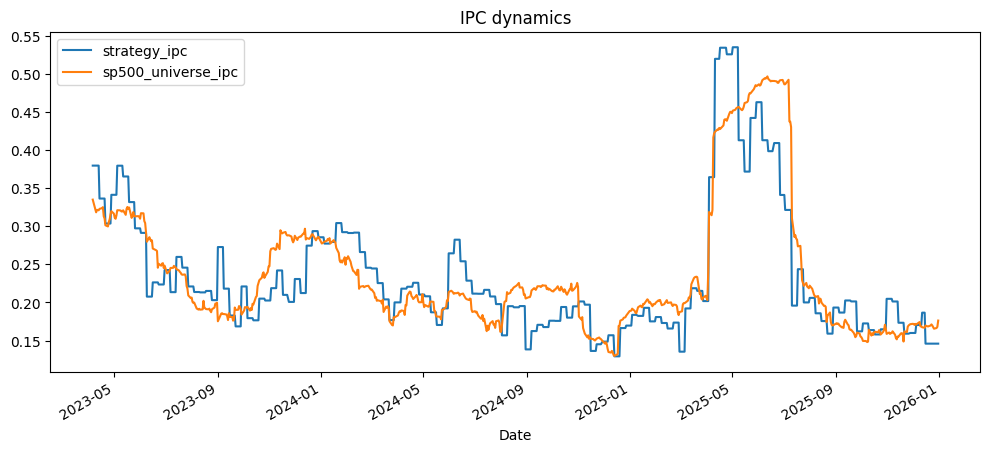

In [18]:
# IPC dynamics: strategy vs S&P500 universe
ipc_path = Path('equity_project/artifacts/metrics/backtest_ipc.parquet')
if ipc_path.exists():
    ipc = pd.read_parquet(ipc_path)
    display(ipc.tail())
    ipc.plot(figsize=(12, 5), title='IPC dynamics')

pnl.png


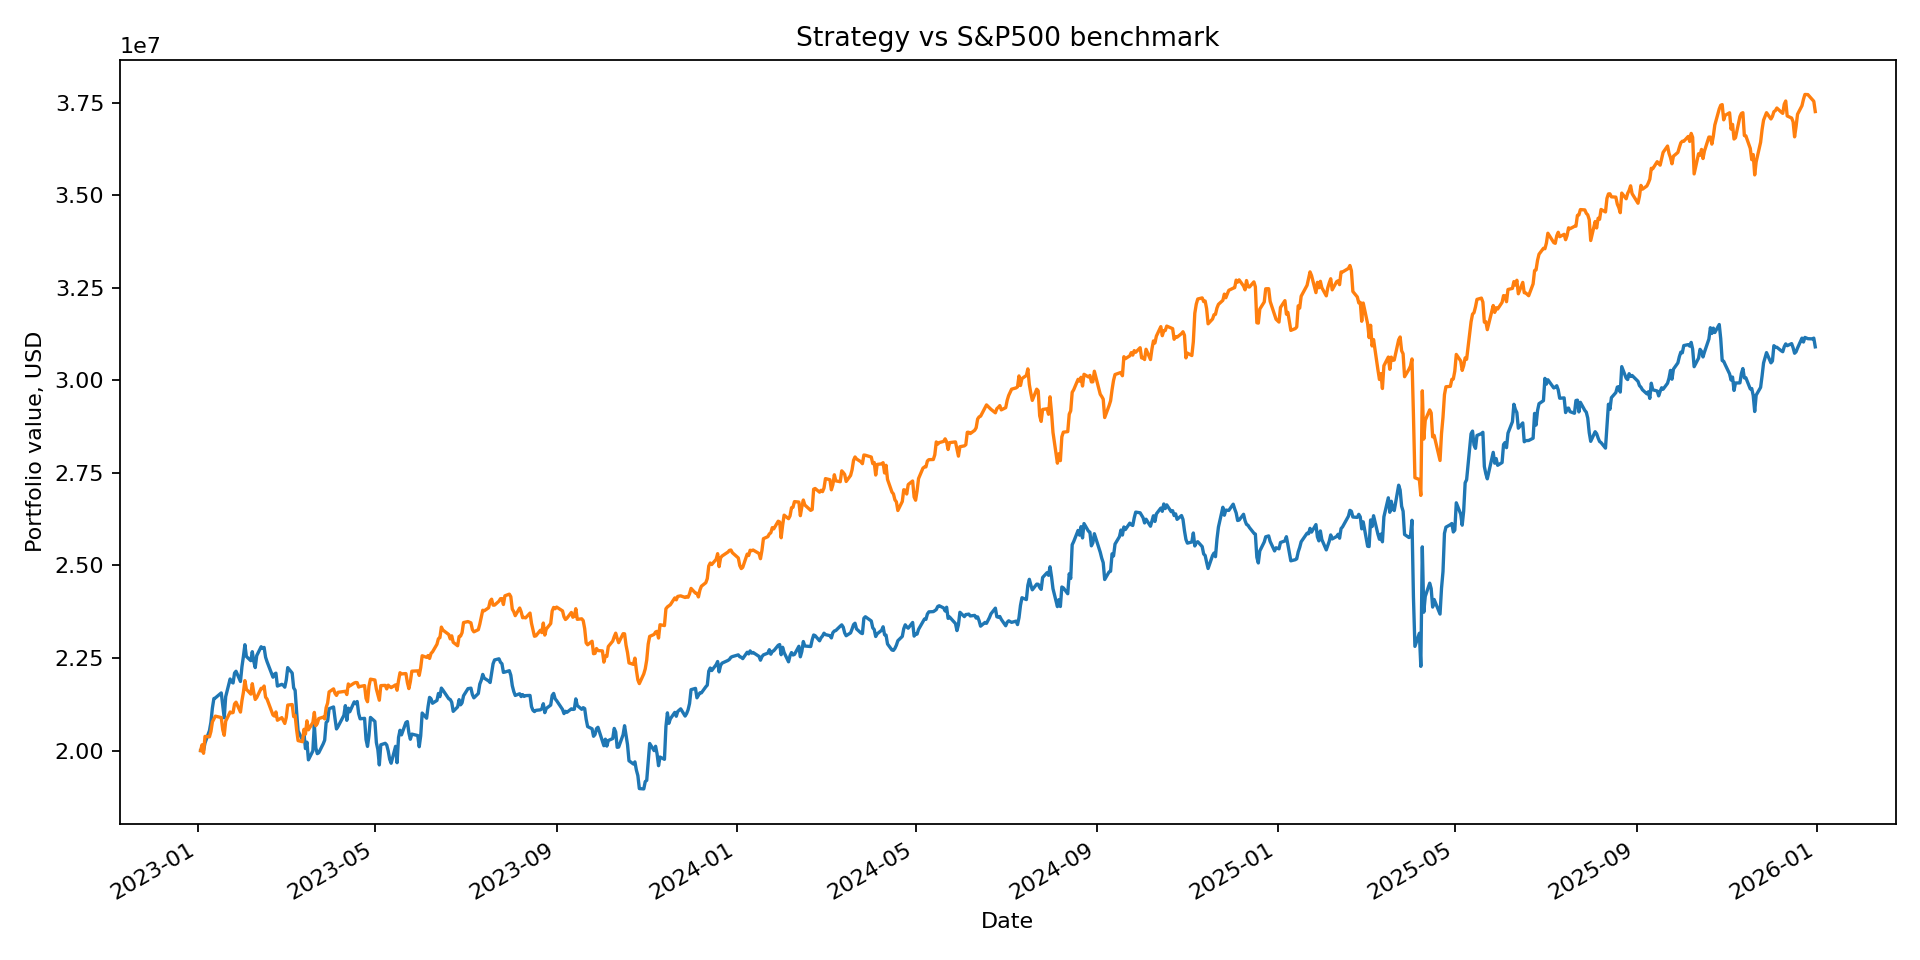

drawdown.png


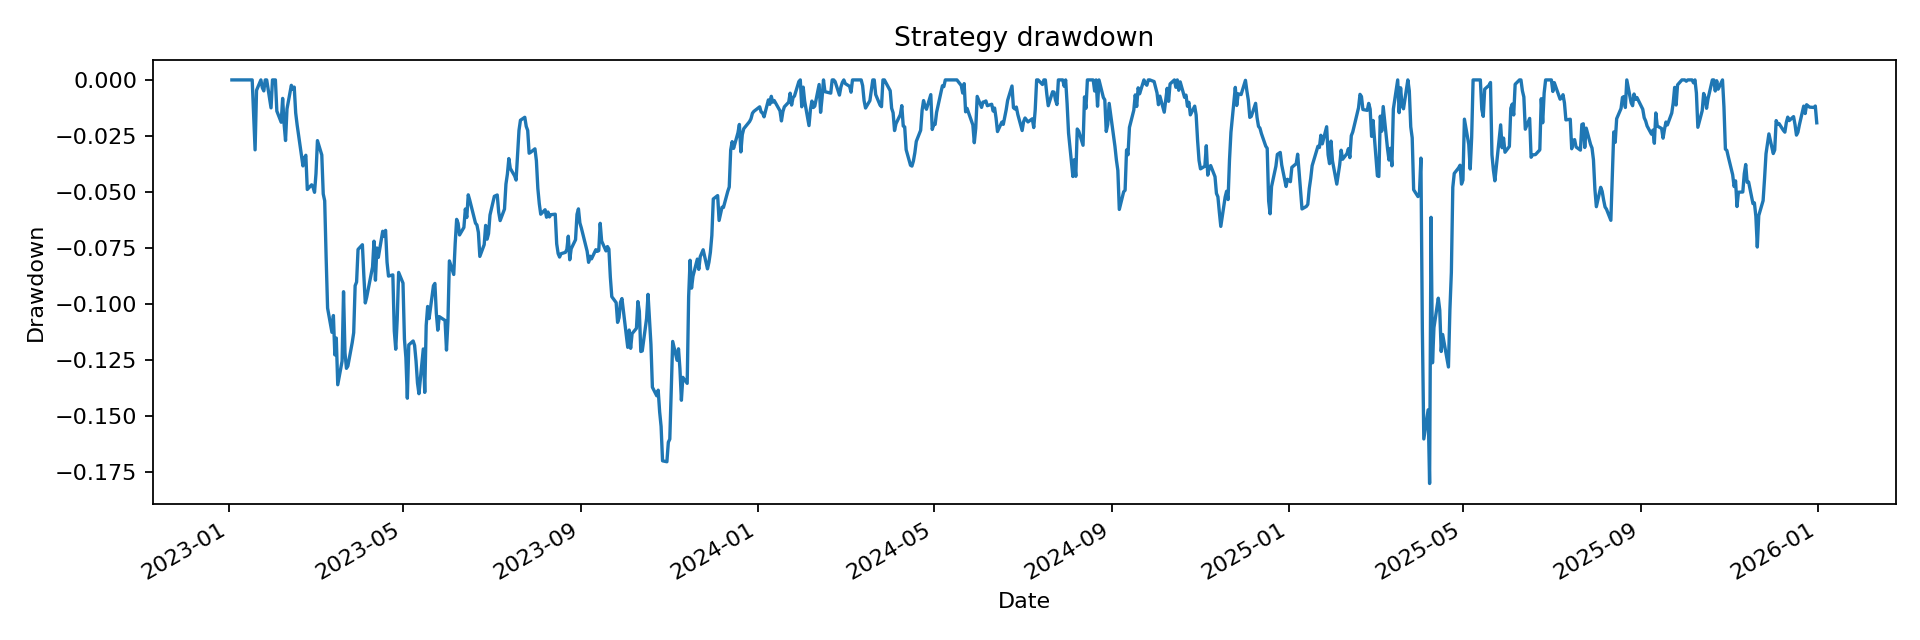

ipc.png


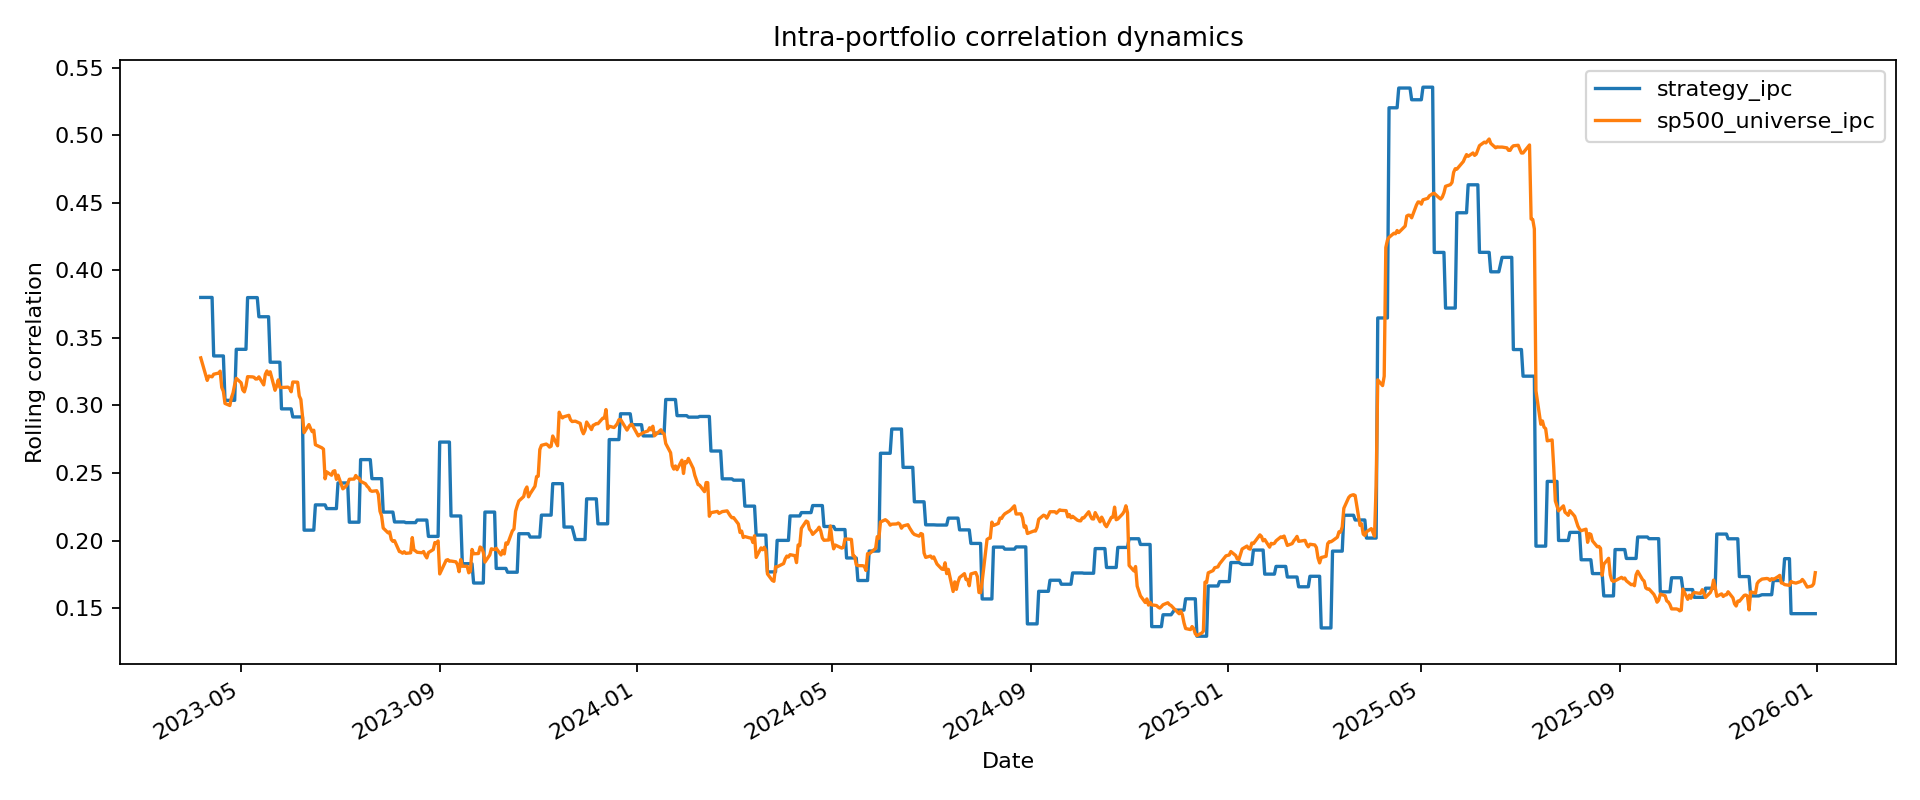

cpcv_backtest_pnl.png


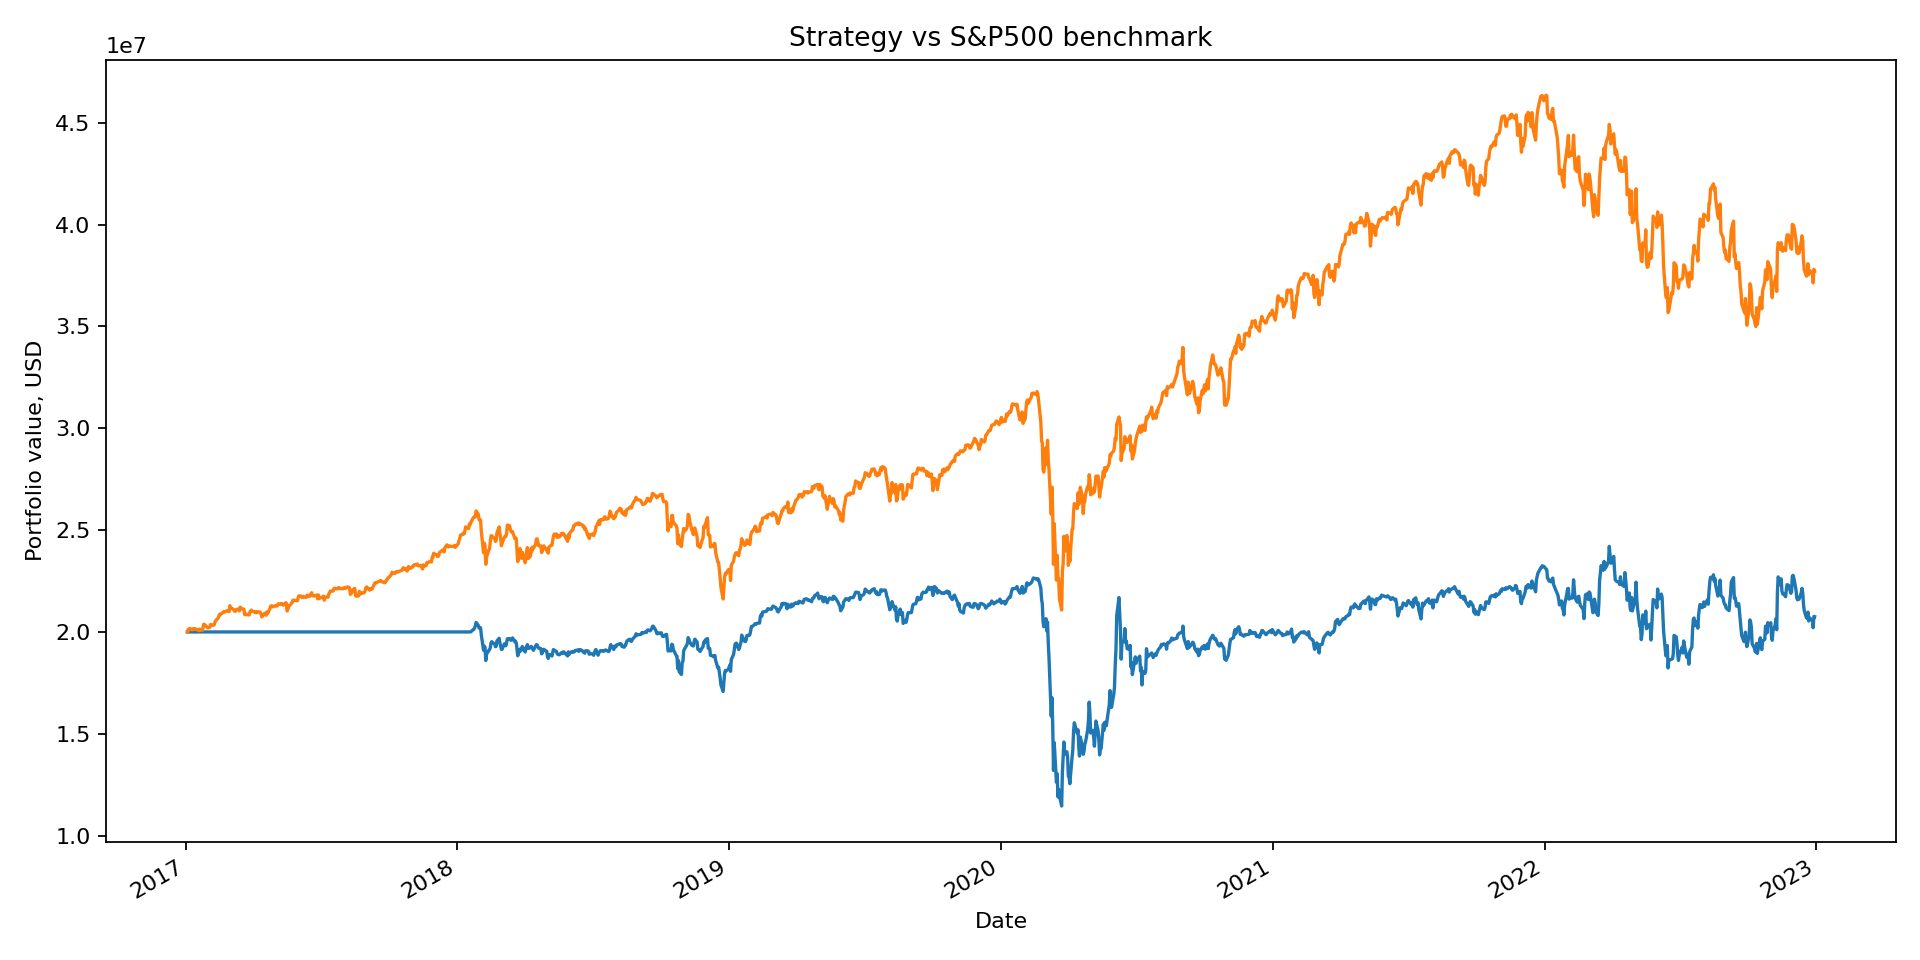

In [19]:

from IPython.display import Image, display

for image_name in ['pnl.png', 'drawdown.png', 'ipc.png', 'cpcv_backtest_pnl.png']:
    image_path = Path('equity_project/artifacts/plots') / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))